In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset.csv')

In [3]:
df = df.drop('Unnamed: 0', axis = 1)

In [4]:
df.sample(5)

,url_length,domain_length,subdomain_length,path_length,._count,-_count,__count,/_count,?_count,=_count,...,special_char_count,digit_ratio,letter_ratio,has_ip,entropy,word_count,keyword_count,suspicious_tld,https,Target
40407,24,8,12,24,2,0,0,0,0,0,...,2,0.000000,0.916667,0,3.553509,3,0,0,0,1
21431,37,5,0,10,2,3,0,1,1,1,...,8,0.135135,0.648649,0,4.208925,8,0,0,0,0
43830,15,7,3,15,2,0,0,0,0,0,...,2,0.133333,0.733333,0,3.506891,3,0,0,0,1
1892,20,8,8,20,2,0,0,0,0,0,...,2,0.000000,0.900000,0,3.784184,3,0,0,0,1
18324,138,11,3,138,3,11,0,4,0,0,...,18,0.086957,0.782609,0,4.495326,19,0,0,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [41]:
x_train, x_test, y_train, y_test = train_test_split(
    df.iloc[:, :-1], df.iloc[:, -1], test_size=0.2, random_state=42, stratify=df.iloc[:,-1]
)

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

In [46]:
confusion_mat = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)
confusion_mat

,Predicted Legitimate,Predicted Phishing
Actual Legitimate,4532,110
Actual Phishing,430,4928


In [47]:
accuracy_score(y_test, y_pred)*100

94.6

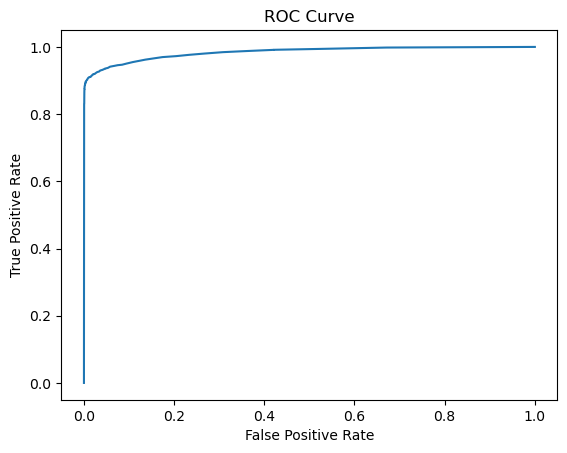

AUC: 0.9840705768564894


In [48]:
y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

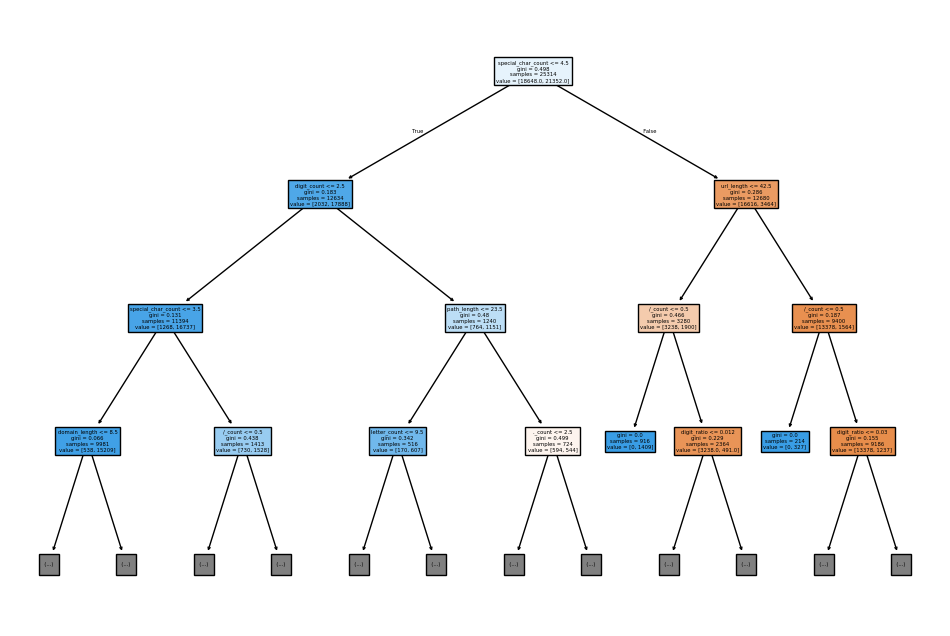

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model.estimators_[0],
          feature_names=x_train.columns,
          filled=True,
          max_depth=3)
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)

param_grid =  {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9481999999999999
